# Set 15 – PyTorch: Architektur + gespeicherte Gewichte
Wir trainieren ein kleines Netz auf den 8×8-Ziffernbildern aus NN2 und speichern dessen `state_dict`. Die Architektur steht in `model_code.py`; JSON beschreibt ihre Größen und das Preprocessing. Es wird nur die CPU-Version benötigt, kein Modelldownload.

Ein `state_dict` ist kein fertiges Python-Modell: Zum Laden wird zuerst dieselbe Architektur aufgebaut.

In [1]:
from pathlib import Path
import sys
kandidaten=[Path.cwd(),*Path.cwd().parents]
set_ordner=next(p for basis in kandidaten for p in (basis,basis/'set15-modelle-speichern-und-laden') if (p/'deployment_tools.py').exists())
if str(set_ordner) not in sys.path:sys.path.insert(0,str(set_ordner))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from deployment_tools import ARTEFAKTE,umgebung,json_speichern,eingaben_pruefen,neuer_prozess

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader,TensorDataset
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from model_code import ZiffernNetz,bilder_vorbereiten
assert torch.version.cuda is None,'CPU-Wheels aus requirements-cpu.txt installieren.'
torch.set_num_threads(2);torch.manual_seed(42)
print('PyTorch:',torch.__version__,'Gerät: cpu','CUDA-Build:',torch.version.cuda)
digits=load_digits()
train_ids,test_ids=train_test_split(np.arange(len(digits.target)),test_size=0.25,random_state=42,stratify=digits.target)
x=bilder_vorbereiten(digits.images)
y=torch.tensor(digits.target,dtype=torch.long)
architektur={'hidden':32,'klassen':10}
modell=ZiffernNetz(**architektur).to('cpu')
train_loader=DataLoader(TensorDataset(x[train_ids],y[train_ids]),batch_size=64,shuffle=True,generator=torch.Generator().manual_seed(42),num_workers=0)
print(modell)

PyTorch: 2.14.1+cpu Gerät: cpu CUDA-Build: None
ZiffernNetz(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=32, out_features=10, bias=True)
  )
)


## 1. Einmal trainieren
20 Epochen sind vorab festgelegt; die Testbilder dienen nicht zum Auswählen der Epochen. Der feste Pixel-Divisor 16 benötigt keinen Fit. Dropout ist beim Training aktiv.

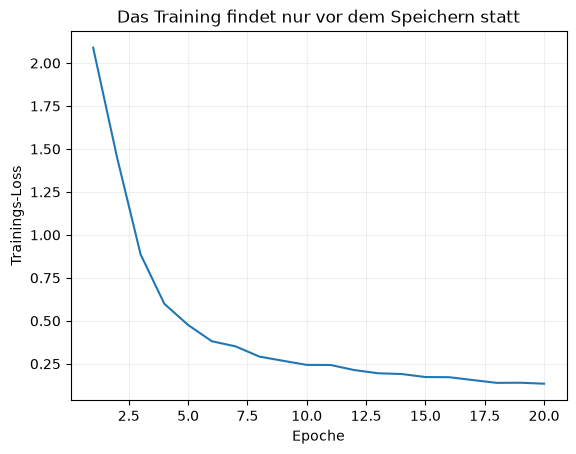

Test-Accuracy: 0.9688888788223267


In [3]:
optimizer=torch.optim.Adam(modell.parameters(),lr=0.005)
loss_fn=nn.CrossEntropyLoss();verluste=[]
for epoche in range(20):
    modell.train();loss_sum=0
    for xb,yb in train_loader:
        optimizer.zero_grad(set_to_none=True)
        loss=loss_fn(modell(xb),yb);loss.backward();optimizer.step()
        loss_sum+=float(loss.detach())*len(yb)
    verluste.append(loss_sum/len(train_ids))
plt.plot(range(1,21),verluste);plt.xlabel('Epoche');plt.ylabel('Trainings-Loss');plt.title('Das Training findet nur vor dem Speichern statt');plt.grid(alpha=0.2);plt.show()
modell.eval()
with torch.inference_mode():vorher=modell(x[test_ids]).softmax(1)
print('Test-Accuracy:',float((vorher.argmax(1)==y[test_ids]).float().mean()))

## 2. Gewichte und Begleitinformationen speichern
`gewichte.pt` enthält nur den `state_dict`. Die Konfiguration legt die Architektur und Pixelverarbeitung fest. Für das Fortsetzen eines Trainings wären zusätzlich Optimizer-Zustand und weitere Trainingsinformationen nötig; hier geht es um Inference.

In [4]:
ordner=ARTEFAKTE/'pytorch_ziffern';ordner.mkdir(exist_ok=True)
torch.save(modell.state_dict(),ordner/'gewichte.pt')
config={'architektur':architektur,'pixel_divisor':16.0,'eingabe':'N × 8 × 8, Pixelwerte 0–16','klassen':list(range(10))}
json_speichern(ordner/'config.json',config)
json_speichern(ordner/'versionen.json',umgebung(['torch','numpy','scikit-learn']))
import shutil
shutil.copy2(set_ordner/'model_code.py',ordner/'model_code.py')
print('Gespeichert:',[p.name for p in ordner.iterdir()])

Gespeichert: ['config.json', 'gewichte.pt', 'model_code.py', 'versionen.json']


## 3. Auf CPU laden und Inference aktivieren
`map_location="cpu"` legt das Ladegerät fest. `weights_only=True` beschränkt das Laden auf Gewichte und unterstützte einfache Daten. `strict=True` prüft passende Schlüssel und Formen.

`eval()` schaltet unter anderem Dropout auf Inference. `inference_mode()` deaktiviert die Gradientenverwaltung. Beide erfüllen verschiedene Aufgaben; `eval()` allein schaltet Gradienten nicht aus.

In [5]:
geladen=ZiffernNetz(**config['architektur']).to('cpu')
state=torch.load(ordner/'gewichte.pt',map_location='cpu',weights_only=True)
print(geladen.load_state_dict(state,strict=True))
geladen.eval()
with torch.inference_mode():nachher=geladen(x[test_ids]).softmax(1)
torch.testing.assert_close(nachher,vorher,rtol=0,atol=0)
print('Alle Test-Vorhersagen vor/nach dem Laden sind identisch.')

<All keys matched successfully>
Alle Test-Vorhersagen vor/nach dem Laden sind identisch.


## 4. Wirklich in einem neuen Prozess verwenden
Die Anwendung bekommt rohe 8×8-Pixel und liest ihre Verarbeitung aus der gespeicherten Konfiguration. Sie greift nicht auf die Trainingsdaten zu. Toleranzen im Vergleich berücksichtigen kleine numerische Unterschiede durch andere Batchgrößen.

Neuer Python-Prozess: Modell geladen; Vorhersagen ohne Training: 6


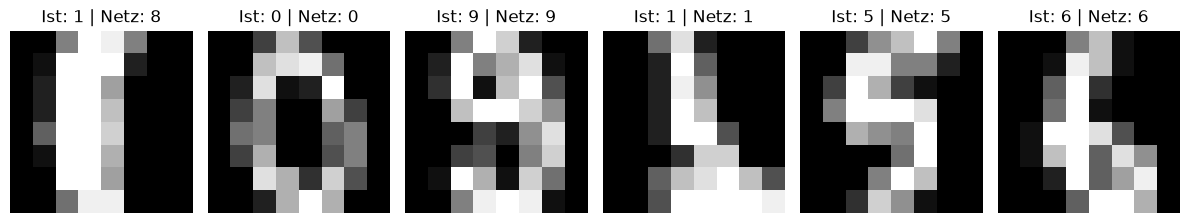

Neuer Prozess: gleiche Klassen und Wahrscheinlichkeiten innerhalb der Toleranz.


In [6]:
probe_ids=test_ids[:6]
extern=neuer_prozess('pytorch',ordner,digits.images[probe_ids].tolist())
np.testing.assert_allclose(extern['wahrscheinlichkeiten'],vorher[:6].numpy(),rtol=1e-5,atol=1e-6)
assert extern['labels']==vorher[:6].argmax(1).tolist()
fig,axes=plt.subplots(1,6,figsize=(12,2.5))
for i,ax in enumerate(axes):
    ax.imshow(digits.images[probe_ids[i]],cmap='gray',vmin=0,vmax=16)
    ax.set_title(f"Ist: {digits.target[probe_ids[i]]} | Netz: {extern['labels'][i]}");ax.axis('off')
plt.tight_layout();plt.show()
print('Neuer Prozess: gleiche Klassen und Wahrscheinlichkeiten innerhalb der Toleranz.')

## 5. Fehler verstehen
Eine andere Schichtgröße passt nicht zu den gespeicherten Gewichten. Die Architektur wird nicht aus der Datei erraten. Wir prüfen auch, dass unpassende Bilder schon vor dem Modell abgewiesen werden.

In [7]:
try:
    ZiffernNetz(hidden=16).load_state_dict(state,strict=True)
except RuntimeError as exc:print('Erwarteter Architekturfehler:',str(exc).splitlines()[0])
else:raise AssertionError('Falsche Architektur wurde nicht erkannt.')
try:
    bilder_vorbereiten(np.zeros((1,7,8)))
except ValueError as exc:print('Erwarteter Bildfehler:',exc)
else:raise AssertionError('Falsche Bildform wurde nicht erkannt.')

Erwarteter Architekturfehler: Error(s) in loading state_dict for ZiffernNetz:
Erwarteter Bildfehler: Erwartet wird ein nichtleeres Batch N × 8 × 8.


Quelle: [PyTorch: Saving and Loading Models](https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html). Datenherkunft und CC-BY-Attribution: `set14-neuronale-netze-nn2/daten/README.md`. PDF-Bezug: Seiten 4, 8–9 und 12–13.